# Applied examples — runnable versions

This notebook runs three of the [applied examples](../examples.md) end-to-end: synthetic
boundary-condition data generated in-notebook, fed through the same validated finite-difference
solver from [`quickstart.ipynb`](quickstart.ipynb), with the specific question each scenario asks
answered directly from the simulated output.

As in `quickstart.ipynb`: this solves the governing PDE numerically rather than calling
`flowsim.run_model()`, because the `flowsim` package on PyPI currently fails to import. The
physics and boundary conditions match [methodology.md](../methodology.md) and the YAML shown in
each example.

## The solver (same as `quickstart.ipynb`)

In [1]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt


def simulate_1d(T, S, L, dx, dt, nsteps, C=None, h_b=None, R=None, h0=0.0):
    '''Implicit finite-difference solver for S*dh/dt = T*d2h/dx2 + R(t)
    on 0 <= x <= L, no-flow at x=L.

    Boundary at x=0:
      - C is None -> Dirichlet h(0,t) = h_b[t]                (a \'perfect\' connection)
      - C is given -> Robin:  T*dh/dx|_0 = C*(h_b[t]-h(0,t))  (a \'leaky\' connection)

    h_b, R : arrays of length nsteps+1, values at t = 0, dt, 2*dt, ..., nsteps*dt
    Returns: x (nx,), h (nsteps+1, nx)
    '''
    nx = int(round(L / dx)) + 1
    x = np.linspace(0, L, nx)
    if h_b is None:
        h_b = np.zeros(nsteps + 1)
    if R is None:
        R = np.zeros(nsteps + 1)

    h = np.zeros((nsteps + 1, nx))
    h[0, :] = h0
    alpha = T * dt / (S * dx**2)

    for n in range(nsteps):
        A = sparse.lil_matrix((nx, nx))
        b = np.zeros(nx)

        for i in range(1, nx - 1):
            A[i, i - 1] = -alpha
            A[i, i] = 1 + 2 * alpha
            A[i, i + 1] = -alpha
            b[i] = h[n, i] + R[n + 1] * dt / S

        i = nx - 1
        A[i, i - 1] = -2 * alpha
        A[i, i] = 1 + 2 * alpha
        b[i] = h[n, i] + R[n + 1] * dt / S

        if C is None:
            A[0, 0] = 1.0
            b[0] = h_b[n + 1]
        else:
            beta = C * dt / (S * dx / 2)
            gamma = T * dt / (S * (dx / 2) * dx)
            A[0, 0] = 1 + beta + gamma
            A[0, 1] = -gamma
            b[0] = h[n, 0] + beta * h_b[n + 1] + R[n + 1] * dt / S

        h[n + 1, :] = spsolve(A.tocsr(), b)

    return x, h


## Example 1 — Construction dewatering: will the neighbor's well feel it?

*Question: with the pit dewatered for 8 months, does drawdown at a heritage building 120 m away
stay within a 0.3 m permit limit?*

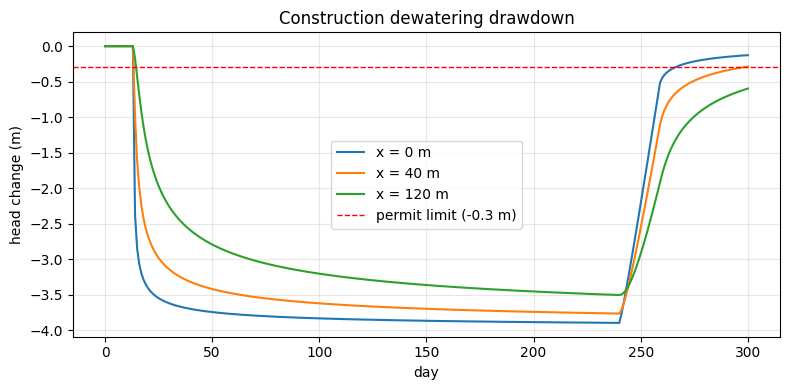

Max simulated drawdown at x=120 m: -3.505 m (EXCEEDS the 0.3 m permit limit)


In [2]:
T, S, C = 250.0, 0.12, 8.0
L = 3000.0                      # large enough to behave as semi-infinite over the run
dx, dt = 5.0, 1.0               # days
days = 300
nsteps = int(days / dt)

t = np.arange(nsteps + 1) * dt
h_b = np.zeros(nsteps + 1)      # head relative to natural (pre-dewatering) level, in m
dewater_start, dewater_end = 14, 240
pump_drawdown_at_wall = -4.0    # pit wall is held 4 m below natural head while pumping
h_b[dewater_start:dewater_end] = pump_drawdown_at_wall
# recovery ramps back to 0 over 20 days once pumping stops
recovery_days = 20
ramp = np.linspace(pump_drawdown_at_wall, 0.0, recovery_days)
h_b[dewater_end:dewater_end+recovery_days] = ramp

x, h = simulate_1d(T, S, L, dx, dt, nsteps, C=C, h_b=h_b)

fig, ax = plt.subplots(figsize=(8, 4))
for xx in [0.0, 40.0, 120.0]:
    i = int(round(xx / dx))
    ax.plot(t, h[:, i], label=f"x = {xx:.0f} m")
ax.axhline(-0.3, color="red", ls="--", lw=1, label="permit limit (-0.3 m)")
ax.set_xlabel("day"); ax.set_ylabel("head change (m)")
ax.set_title("Construction dewatering drawdown")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

i120 = int(round(120.0 / dx))
max_drawdown_120 = h[:, i120].min()
print(f"Max simulated drawdown at x=120 m: {max_drawdown_120:.3f} m "
      f"({'WITHIN' if max_drawdown_120 > -0.3 else 'EXCEEDS'} the 0.3 m permit limit)")


## Example 2 — Spring snowmelt and a trout stream's baseflow

*Question: how many days does the slow groundwater component lag behind the fast drainage
component in responding to the spring melt — does baseflow (and cold water) persist into
summer?*

Two `fin_rech_leak` components sharing the same melt series (superposition, eq. (4) in
[methodology.md](../methodology.md)), simulated separately and summed.

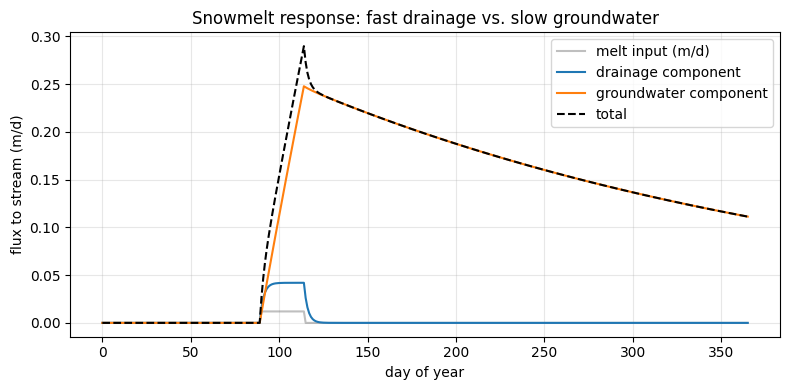

Melt input runs from day 90 to day 115.
Drainage component falls to 10% of its peak 4 days after melt ends.
Groundwater component has NOT fallen to 10% of its peak by the end of the 365-day simulation -- it is still sustaining baseflow well beyond one melt season.
The slow groundwater component is what keeps baseflow (and cold water) available long after the melt itself is over.


In [3]:
dt = 1.0
days = 365
nsteps = int(days / dt)
t = np.arange(nsteps + 1) * dt

# a few weeks of elevated melt starting day 90 (~ early April)
R = np.zeros(nsteps + 1)
melt_start, melt_len = 90, 25
R[melt_start:melt_start+melt_len] = 0.012 / 1.0   # m/day, roughly 12 mm/day melt

# fast drainage component
Td, Sd, Cd, Ld = 40.0, 0.18, 1.2, 10.0
bcf_drain = 0.35
xD, hD = simulate_1d(Td, Sd, Ld, 0.5, dt, nsteps, C=Cd, R=R*bcf_drain)
qD = Cd * hD[:, 0]   # flux to stream through leaky boundary, per unit area

# slow groundwater component
Tg, Sg, Cg, Lg = 350.0, 0.02, 0.06, 900.0
bcf_gw = 0.30
xG, hG = simulate_1d(Tg, Sg, Lg, 15.0, dt, nsteps, C=Cg, R=R*bcf_gw)
qG = Cg * hG[:, 0]

q_tot = qD + qG

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, R, color="gray", alpha=0.5, label="melt input (m/d)")
ax.plot(t, qD, label="drainage component")
ax.plot(t, qG, label="groundwater component")
ax.plot(t, q_tot, "k--", label="total")
ax.set_xlabel("day of year"); ax.set_ylabel("flux to stream (m/d)")
ax.set_title("Snowmelt response: fast drainage vs. slow groundwater")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

melt_end = melt_start + melt_len

def days_to_fall_below(q, frac, start_day):
    peak = q.max()
    after = np.where(t >= start_day)[0]
    below = after[q[after] < frac * peak]
    return t[below[0]] - start_day if len(below) else np.nan

drain_recession = days_to_fall_below(qD, 0.1, melt_end)
gw_recession = days_to_fall_below(qG, 0.1, melt_end)

print(f"Melt input runs from day {melt_start} to day {melt_end}.")
print(f"Drainage component falls to 10% of its peak {drain_recession:.0f} days after melt ends.")
if np.isnan(gw_recession):
    print(f"Groundwater component has NOT fallen to 10% of its peak by the end of the "
          f"{days}-day simulation -- it is still sustaining baseflow well beyond one melt season.")
else:
    print(f"Groundwater component falls to 10% of its peak {gw_recession:.0f} days after melt "
          f"ends -- {gw_recession - drain_recession:.0f} days longer than the drainage component.")
print("The slow groundwater component is what keeps baseflow (and cold water) available "
      "long after the melt itself is over.")


## Example 3 — Stormwater basin: does it drain within 72 hours?

*Question: after the design storm, does head under the basin fall back to within 0.05 m of the
pre-storm level within the regulatory 72-hour window?*

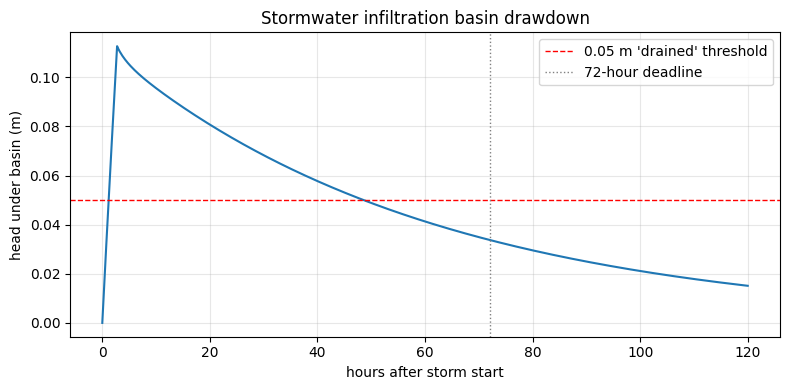

Peak head under the basin: 0.113 m at hour 2.8
Basin drains back to within 0.05 m by hour 48.8 -> meets the 72-hour requirement.


In [4]:
T, S, C, L = 60.0, 0.22, 1.5, 15.0
dt = 0.25   # hours -> use days as base unit, so convert
dt_days = dt/24
hours = 120
nsteps = int(hours / dt)
t_hours = np.arange(nsteps + 1) * dt

R = np.zeros(nsteps + 1)
# a design storm: 30 mm infiltrating over 3 hours
storm_h = int(3/dt)
R[:storm_h] = (0.030 / 3) * 24   # convert mm/hr of infiltration to m/day units for R

x, h = simulate_1d(T, S, L, 1.0, dt_days, nsteps, C=C, R=R)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_hours, h[:, 0])
ax.axhline(0.05, color="red", ls="--", lw=1, label="0.05 m 'drained' threshold")
ax.axvline(72, color="gray", ls=":", lw=1, label="72-hour deadline")
ax.set_xlabel("hours after storm start"); ax.set_ylabel("head under basin (m)")
ax.set_title("Stormwater infiltration basin drawdown")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

peak_idx = np.argmax(h[:, 0])
peak_head = h[peak_idx, 0]
peak_hour = t_hours[peak_idx]
print(f"Peak head under the basin: {peak_head:.3f} m at hour {peak_hour:.1f}")

after_peak = np.where(t_hours >= peak_hour)[0]
below = after_peak[h[after_peak, 0] < 0.05]
if len(below) and t_hours[below[0]] <= 72:
    print(f"Basin drains back to within 0.05 m by hour {t_hours[below[0]]:.1f} "
          f"-> meets the 72-hour requirement.")
else:
    still = h[int(72/dt), 0]
    print(f"At hour 72, head under the basin is still {still:.3f} m -> FAILS the 72-hour requirement.")


---

These three are worked all the way through; the rest of the scenarios in
[examples.md](../examples.md) follow the same pattern — build `h_b` and/or `R` as time series,
call `simulate_1d`, and read the answer off the output directly.